# 76 - Custom Loss Functions

**Section:** CNNs | **Prereqs:** `CNNs/Discovering_Gaussian_Parameters.ipynb` | **Next:** `CNNs/DoAutoEncoders_CleanGaussians_(CNN_AE).ipynb`

The loss defines the goal. When none of the built-in losses expresses what you
actually want, write one - it is an `nn.Module` with a `forward` that returns a
scalar built from differentiable torch operations. Autograd handles the rest;
there is no gradient to derive by hand.

**Three losses, compared by training the same autoencoder with each**

| Loss | Formula | What it optimises |
|---|---|---|
| **L1** | `mean(\|yhat - y\|)` | median-like; robust to outliers, tends to produce sharper images |
| **L2 + mean penalty** | `mean((yhat-y)^2) + \|mean(yhat)\|` | accuracy plus a push towards zero-mean output |
| **Correlation** | `-corr(yhat, y)` | *shape* only - scale and offset are free |

**The correlation loss is the interesting one.** Correlation is invariant to scale
and offset, so a reconstruction with the right pattern but the wrong brightness
scores perfectly. Use it when the pattern matters and the units do not - and note
the minus sign, because optimizers minimise, so maximising correlation means
minimising its negative.

**Two rules for writing a loss**
1. Use torch ops on tensors, never `.item()` or numpy - either breaks the graph
   and `backward()` will fail or silently do nothing.
2. Return a scalar. Reduce with `.mean()` or `.sum()`.

**Fail loudly on a shape mismatch.** Each `forward` raises if the shapes differ.
The tempting alternative - `if yhat.shape == y.shape:` with no `else` - returns
`None`, and the error then surfaces much later as an `AttributeError` inside
`backward()`, a long way from its cause.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchsummary import summary

## Making Custom Loss Functions

In [ ]:
# A custom L1 (mean absolute error) loss. The whole interface: subclass
# nn.Module, implement forward(yhat, y), return a scalar.
# The shape check RAISES on mismatch. Returning None instead would surface much
# later as a confusing AttributeError inside backward().
class myL1loss(nn.Module):
  def __init__(self) -> None:
    super().__init__()


  def forward(self,yhat,y):
    if yhat.shape != y.shape:
      raise ValueError(f'shape mismatch: {yhat.shape} vs {y.shape}')
    return torch.mean(torch.abs(yhat-y))



In [ ]:
# Two tensors differing by exactly 1, so the expected L1 loss is 1.0.
a = torch.randn(10,10)
b = a+1

In [ ]:
lossfunc = myL1loss()

In [ ]:
# Confirms 1.0 - a unit test for a loss function, which is worth writing for any
# custom loss before trusting it in a training run.
lossfunc(b,a)

tensor(1.)

In [ ]:
b.shape

torch.Size([10, 10])

In [ ]:
b.numel()

100

In [ ]:
# L2 with an extra term penalising a non-zero mean output.
# This is how any regulariser or auxiliary objective is added: sum the terms and
# return one scalar. Autograd differentiates the whole expression.
class myL2Avgloss(nn.Module):
  def __init__(self) -> None:
    super().__init__()


  def forward(self,yhat,y):
    if yhat.shape != y.shape:
      raise ValueError(f'shape mismatch: {yhat.shape} vs {y.shape}')
    return (torch.mean((yhat-y)**2)) + torch.abs(torch.mean(yhat))



In [ ]:
lossfunc = myL2Avgloss()

lossfunc(b,a)

tensor(1.9379)

In [ ]:
# Correlation loss. Correlation is invariant to SCALE and OFFSET, so this asks
# only for the right pattern, not the right values.
# The leading minus sign matters: optimizers minimise, so maximising correlation
# means minimising its negative. Getting that sign wrong trains the model to be
# as wrong as possible - and it is a surprisingly common mistake.
class myCorrloss(nn.Module):
  def __init__(self) -> None:
    super().__init__()


  def forward(self,yhat,y):
    if yhat.shape != y.shape:
      raise ValueError(f'shape mismatch: {yhat.shape} vs {y.shape}')
    n = yhat.numel()

    yhat_mean = torch.mean(yhat)
    yhat_std = torch.std(yhat)

    y_mean = torch.mean(y)
    y_std = torch.std(y)

    return -torch.sum((yhat-yhat_mean) * (y-y_mean)) / ((n-1) * yhat_std * y_std)



In [ ]:
lossfunc = myCorrloss()

lossfunc(b,a)

tensor(-1.)

## Making the data

In [ ]:
# Gaussian blobs with widths spanning 2 to 20, plus OCCLUSION - a random bright
# bar across each image. The autoencoder must reconstruct despite it.
img_size = 91
n_perClass = 1000

sigma = np.linspace(2,20,n_perClass)

x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)

images = np.zeros((n_perClass , 1, img_size,img_size), dtype=float)

for i in range(n_perClass):

  center = 2*np.random.randn(2)

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i]))

  noise = np.random.randn(*G.shape) / 10

  images[i,:,:,:] = G - noise

  # Occulsion
  i1 = np.random.choice(np.arange(2,28))
  i2 = np.random.choice(np.arange(2,6))

  if np.random.randn() > 0:
    images[i,:,i1:i1+i2,:] = 1
  else:
    images[i,:,:,i1:i1+i2] = 1



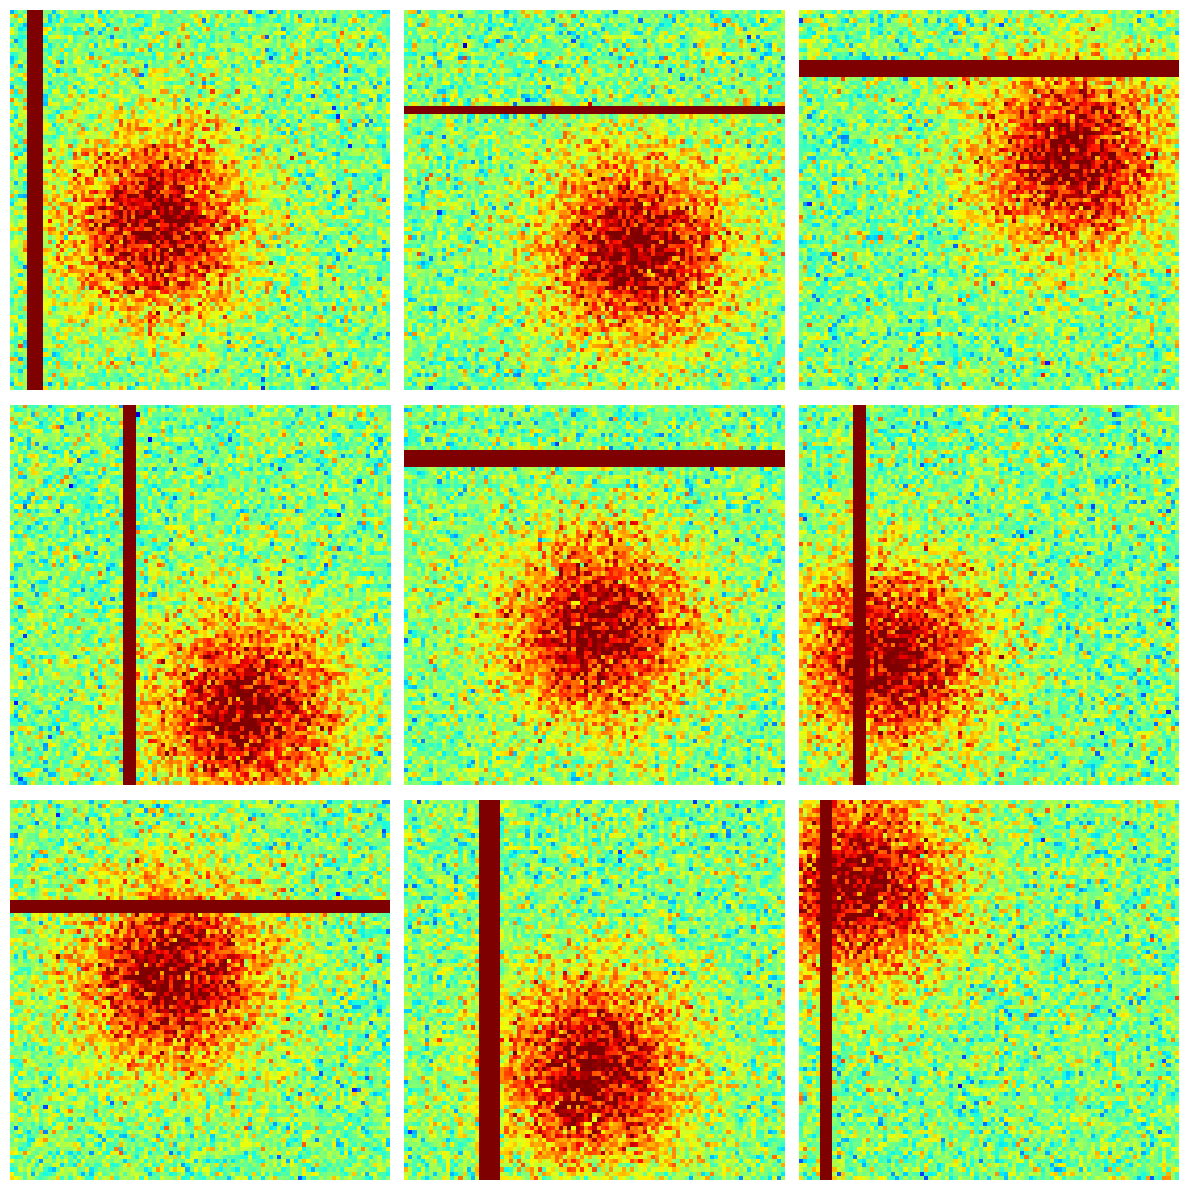

In [ ]:
# Sample images with their occlusion bars.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# TensorDataset with only ONE tensor: an autoencoder's target is its input, so
# there are no labels. That is why the loop below unpacks x[0].
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_tensor = torch.tensor(images, dtype=torch.float , device=device)

train_dataset = TensorDataset(train_tensor)

bs = 8
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)


In [ ]:
# A convolutional autoencoder: encoder compresses (1,91,91) to (4,22,22),
# decoder rebuilds it with ConvTranspose2d.
# The compression is the point - the bottleneck forces the model to keep only
# what matters. Covered properly in Autoencoders/.
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ENCODER
        self.enc = nn.Sequential(
            # Input: (1, 91, 91) -> Output after Conv2d+ReLU: (6, 91, 91)
            nn.Conv2d(1, 6, 3,padding = 1),
            nn.ReLU(),
            # Output after MaxPool2d: (6, 45, 45)
            nn.MaxPool2d((2,2)),

            # Input: (6, 45, 45) -> Output after Conv2d+ReLU: (4, 45, 45)
            nn.Conv2d(6,4,3,padding = 1),
            nn.ReLU(),
            # Output after MaxPool2d: (4, 22, 22)
            nn.MaxPool2d((2,2))
        )

        # DECODER
        self.dec = nn.Sequential(
            # Input: (4, 22, 22) -> Output after ConvTranspose2d+ReLU: (6, 45, 45)
            nn.ConvTranspose2d(4,6,3,2),
            nn.ReLU(),

            # Input: (6, 45, 45) -> Output after ConvTranspose2d: (1, 91, 91)
            nn.ConvTranspose2d(6,1,3,2),
            # nn.Tanh()
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x

In [ ]:
test_model = AutoEncoder()
test_model.to(device)

AutoEncoder(
  (enc): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (dec): Sequential(
    (0): ConvTranspose2d(4, 6, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(6, 1, kernel_size=(3, 3), stride=(2, 2))
  )
)

In [ ]:
# torchsummary - check that the decoder's output really is 91x91. Transposed
# convolution sizes are easy to get wrong by a pixel or two.
summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.24
Params size (MB): 0.00
Estimated Total Size (MB): 1.27
---------------------------------------------------

## Training with custom L1 loss

In [ ]:
# Training with the custom L1 loss. Note `loss = lossFunc(yhat, x_batch)` -
# the target IS the input. That is what makes it an autoencoder.
def train_model():

  model = AutoEncoder().to(device)

  lr = 1e-4
  epochs = 1000

  lossFunc = myL1loss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []


  for epoch in range(epochs):

    model.train()
    batch_loss = []

    for x in train_loader:
      x_batch = x[0]
      yhat = model(x_batch)

      loss = lossFunc(yhat, x_batch) # Use the unpacked input to calculate error.
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    losses.append(np.mean(batch_loss))

    if epoch % 100 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]} ')

  return model, losses

In [ ]:
model, losses = train_model()

Epoch : 0 | loss : 0.6284137592315674 
Epoch : 100 | loss : 0.15971394228935243 
Epoch : 200 | loss : 0.15691684591770172 
Epoch : 300 | loss : 0.1546577491760254 
Epoch : 400 | loss : 0.15381419575214386 
Epoch : 500 | loss : 0.15330977642536164 
Epoch : 600 | loss : 0.152956111907959 
Epoch : 700 | loss : 0.15275851607322694 
Epoch : 800 | loss : 0.15261788654327393 
Epoch : 900 | loss : 0.1525229263305664 
Epoch : 999 | loss : 0.1524471127986908 


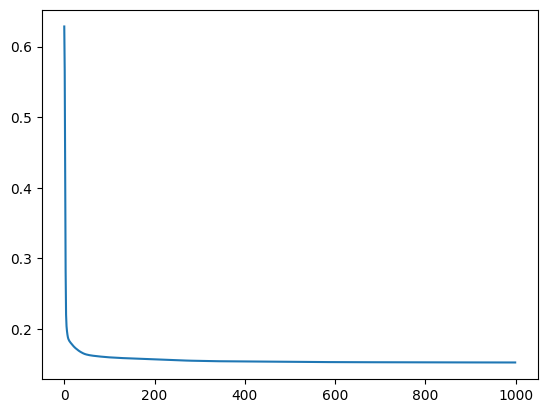

In [ ]:
# Loss curve under L1.
plt.plot(losses);

In [ ]:
subset = train_tensor[2:10]

output = model(subset)

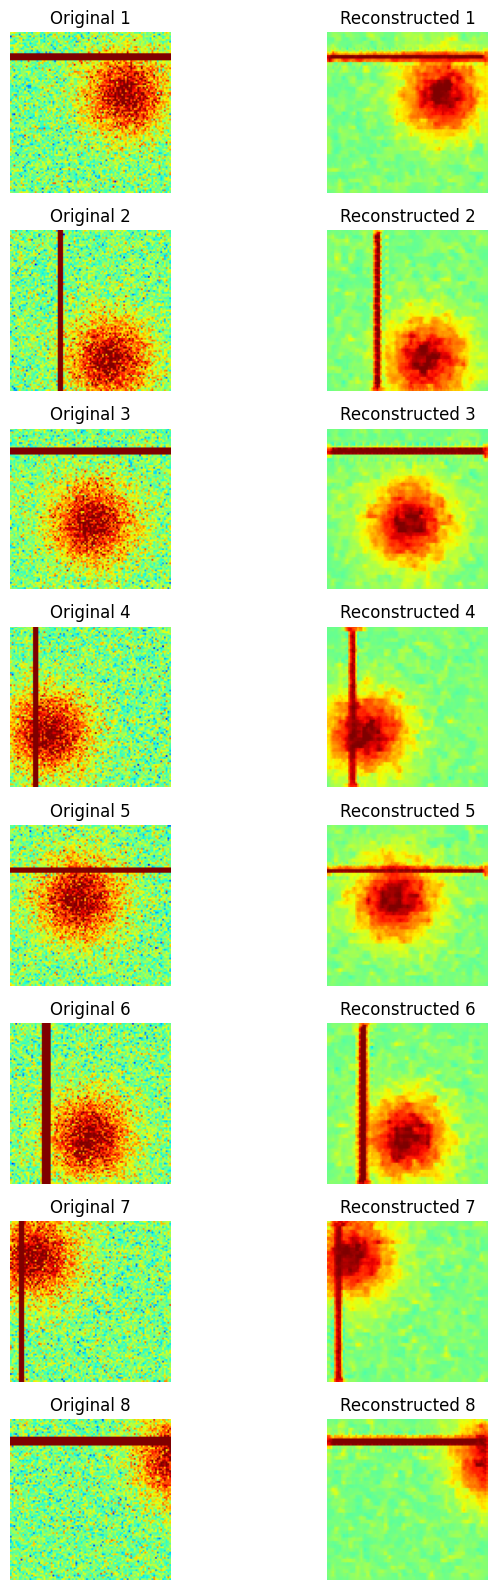

In [ ]:
# Originals vs reconstructions. Look at what happened to the occlusion bars:
# a good autoencoder learns the Gaussian structure and treats the bar as noise
# to be removed - the denoising behaviour explored in Autoencoders/.
num_images_to_display = 8

# Move tensors to CPU and convert to numpy for plotting
input_images_np = subset.detach().cpu().numpy()
output_images_np = output.detach().cpu().numpy()

fig, axes = plt.subplots(num_images_to_display, 2, figsize=(8, num_images_to_display * 2))

for i in range(num_images_to_display):
    # Plot original image
    axes[i, 0].imshow(np.squeeze(input_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    # Plot reconstructed image
    axes[i, 1].imshow(np.squeeze(output_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 1].set_title(f'Reconstructed {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

#

## Training with custom L2 loss

In [ ]:
# The same training with the L2 + mean-penalty loss.
def train_model():

  model = AutoEncoder().to(device)

  lr = 1e-4
  epochs = 1000

  lossFunc = myL2Avgloss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []


  for epoch in range(epochs):

    model.train()
    batch_loss = []

    for x in train_loader:
      x_batch = x[0]
      yhat = model(x_batch)

      loss = lossFunc(yhat, x_batch) # Use the unpacked input to calculate error.
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    losses.append(np.mean(batch_loss))

    if epoch % 100 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]} ')

  return model, losses

In [ ]:
model, losses = train_model()

Epoch : 0 | loss : 0.39632983660697935 
Epoch : 99 | loss : 0.31461157965660097 


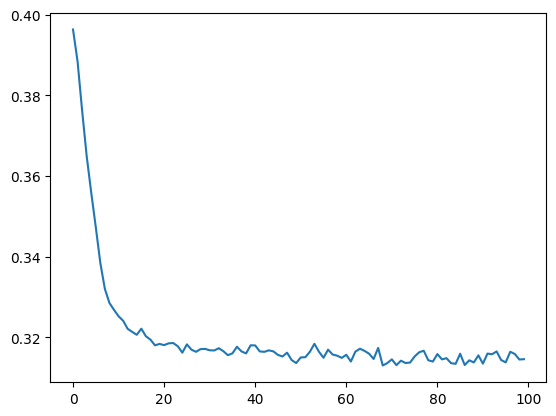

In [ ]:
# Its loss curve. The scale differs from the L1 run, so compare the pictures
# rather than the numbers.
plt.plot(losses);

In [ ]:
subset = train_tensor[2:10]

output = model(subset)

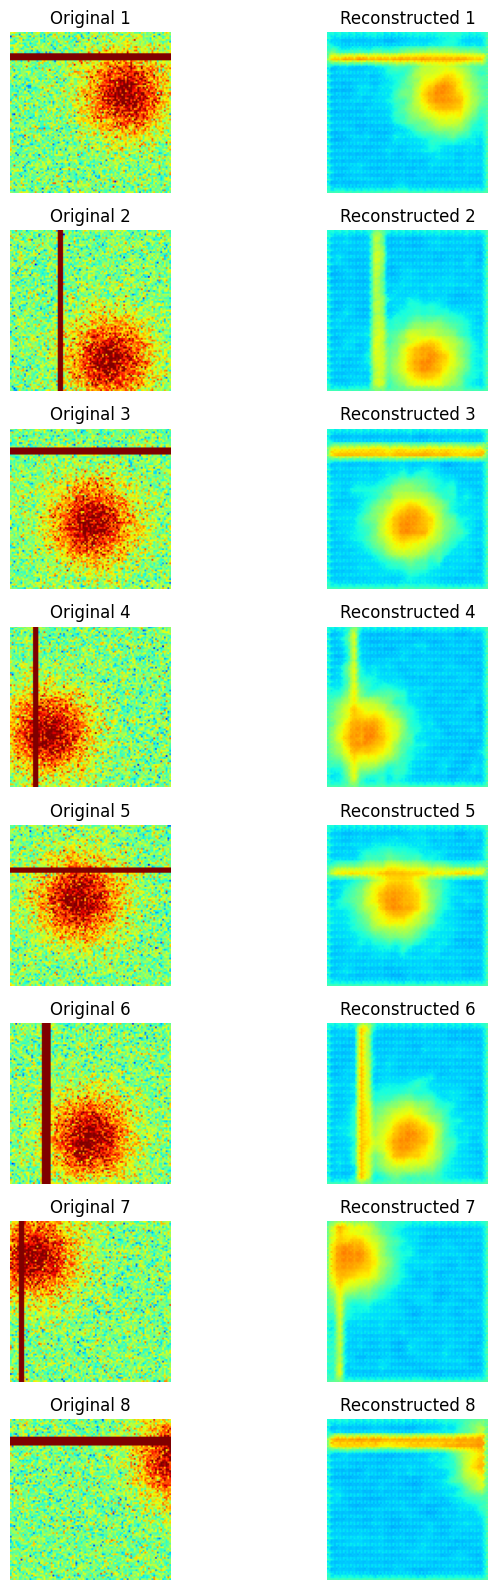

In [ ]:
# Reconstructions under L2. Compare with the L1 results: L2 penalises large
# errors quadratically, so it tends to hedge and blur; L1 gives sharper output.
# This is a real and visible difference in image models, not a technicality.
num_images_to_display = 8

# Move tensors to CPU and convert to numpy for plotting
input_images_np = subset.detach().cpu().numpy()
output_images_np = output.detach().cpu().numpy()

fig, axes = plt.subplots(num_images_to_display, 2, figsize=(8, num_images_to_display * 2))

for i in range(num_images_to_display):
    # Plot original image
    axes[i, 0].imshow(np.squeeze(input_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    # Plot reconstructed image
    axes[i, 1].imshow(np.squeeze(output_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 1].set_title(f'Reconstructed {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

##Training with custom corr loss

In [ ]:
# Training with the correlation loss.
# Its values are in [-1, 0]: -1 is a perfect match. Because it ignores scale and
# offset, the reconstruction can have the right shape at completely the wrong
# brightness and still score perfectly.
def train_model():

  model = AutoEncoder().to(device)

  lr = 1e-4
  epochs = 1000

  lossFunc = myCorrloss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []


  for epoch in range(epochs):

    model.train()
    batch_loss = []

    for x in train_loader:
      x_batch = x[0]
      yhat = model(x_batch)

      loss = lossFunc(yhat, x_batch) # Use the unpacked input to calculate error.
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    losses.append(np.mean(batch_loss))

    if epoch % 100 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]} ')

  return model, losses

In [ ]:
model, losses = train_model()

Epoch : 0 | loss : -0.18047926537692546 
Epoch : 100 | loss : -0.8355110006332398 
Epoch : 200 | loss : -0.8404482922554016 
Epoch : 300 | loss : -0.8419319486618042 
Epoch : 400 | loss : -0.8428201332092286 
Epoch : 500 | loss : -0.8418511843681336 
Epoch : 600 | loss : -0.8430731043815612 
Epoch : 700 | loss : -0.8440332837104797 
Epoch : 800 | loss : -0.844347891330719 
Epoch : 900 | loss : -0.8440379977226258 
Epoch : 999 | loss : -0.8446700687408447 


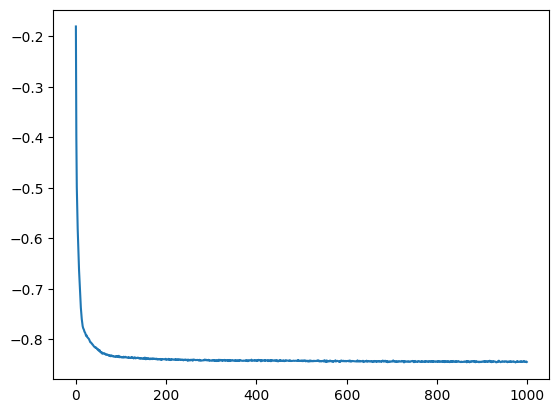

In [ ]:
# The correlation loss curve, heading towards -1.
plt.plot(losses);

In [ ]:
subset = train_tensor[2:10]

output = model(subset)

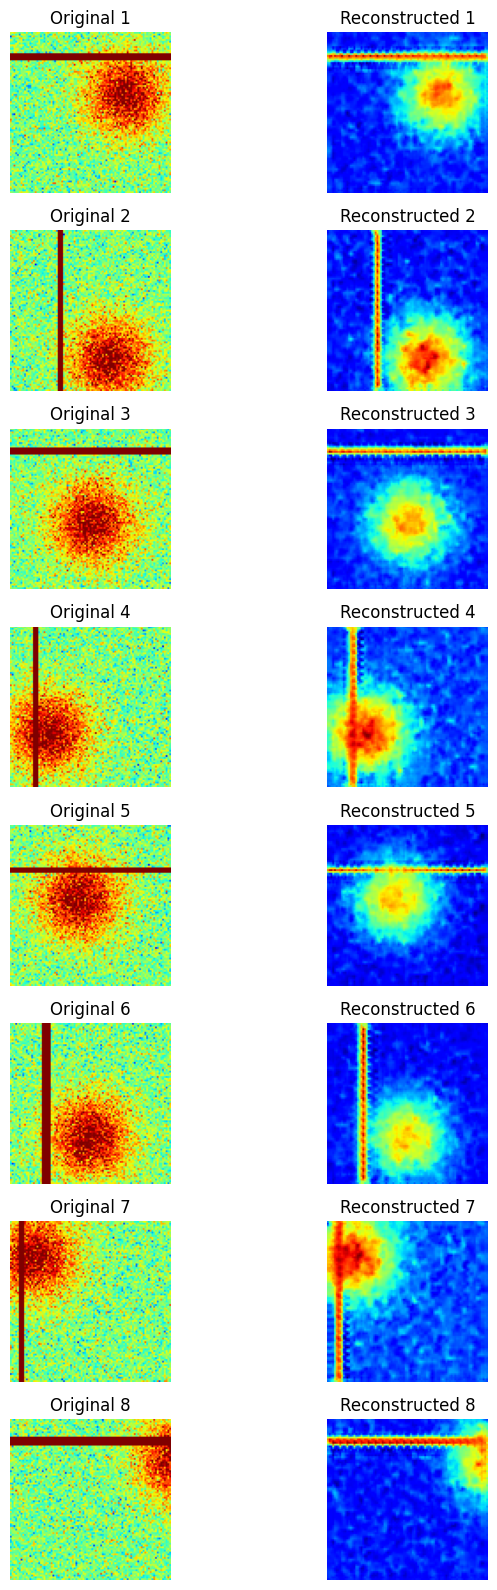

In [ ]:
num_images_to_display = 8

# Move tensors to CPU and convert to numpy for plotting
input_images_np = subset.detach().cpu().numpy()
output_images_np = output.detach().cpu().numpy()

fig, axes = plt.subplots(num_images_to_display, 2, figsize=(8, num_images_to_display * 2))

for i in range(num_images_to_display):
    # Plot original image
    axes[i, 0].imshow(np.squeeze(input_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    # Plot reconstructed image
    axes[i, 1].imshow(np.squeeze(output_images_np[i]), cmap='jet')
    axes[i, 1].set_title(f'Reconstructed {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()